In [215]:
import zarr

dataset_path = '../dataset_generation/full_dataset/dataset.zarr'

# Open the dataset in read mode
root = zarr.open_group(dataset_path, mode='r')

dataset_size = 100

# Access the arrays
X_flux = root["X_flux_coeffs"][:dataset_size]
X_wts  = root["X_weights"][:dataset_size]
Y_flux = root["Y_flux_coeffs"][:dataset_size]
Y_pow  = root["Y_power_coeffs"][:dataset_size]
Y_keff = root["Y_keff"][:dataset_size]
Y_wts  = root["Y_weights"][:dataset_size]

# Convert all of the surface indices to be in standard (ccw) convention
# indexing_convention_to_ccw_mapping = [0, 2, 1, 3]

# def indexing_convention_to_ccw(arr):
#     """Takes in a 4-tuple surface permutation in ccw order and converts it to one in the indexing convention."""

#     # First change the indices that the permutation refers to, from ccw order to the indexing convention.
#     arr = [ indexing_convention_to_ccw_mapping[i] for i in (3, 0, 1, 2) ]

#     # Now, we need to reorder the array to match the indexing convention.
#     arr = [ arr[indexing_convention_to_ccw_mapping[i]] for i in range(4) ]
#     return arr 

# Convert all data into pytorch tensors of the appropriate shape

import numpy as np
import torch

X_flux = np.moveaxis(X_flux, -1, 2)
Y_flux = np.moveaxis(Y_flux, -1, 2)

X_flux = torch.tensor(X_flux, dtype=torch.float32)
X_wts  = torch.tensor(X_wts, dtype=torch.float32)

Y_flux = torch.tensor(Y_flux, dtype=torch.float32)
Y_pow  = torch.tensor(Y_pow, dtype=torch.float32)
Y_keff = torch.tensor(Y_keff, dtype=torch.float32)
Y_wts  = torch.tensor(Y_wts, dtype=torch.float32)

In [216]:
# Flatten and concatenate inputs
X_flux_flat = X_flux.view(X_flux.size(0), -1)
X_input = torch.cat([X_flux_flat, X_wts], dim=1)

# Output sizes
out_flux_size = Y_flux.view(Y_flux.size(0), -1).size(1)
out_pow_size = Y_pow.view(Y_pow.size(0), -1).size(1)
out_wts_size = Y_wts.size(1)
out_keff_size = 1

In [217]:
import torch.nn as nn
import torch.nn.functional as F


def rotate_180_spatial(tensor, pos_encodings=False):
    """Rotate a 5D/6D tensor with shape (surfaces, channels, height, width, depth) or 
    (num_datapoints, surfaces, channels, height, width, depth) by 180 degrees in the 
    height and width dimensions.
    
    Parameters
    ----------
    pos_encodings:
        If True, the input tensor has additional channels corresponding to positional encodings, and we want to only rotate the channels
        corresponding to the base tensor, not the positional encodings.
    """

    num_dims = tensor.dim()
    
    if num_dims not in [5, 6]:
        raise ValueError("Input tensor must be 5D or 6D. Got {}D.".format(num_dims))
    
    if num_dims == 5:
        dims = [2, 3]
        if pos_encodings:
            rotated_tensor = tensor.clone()
            rotated_tensor[:, 0, :, :, :] = tensor[:, 0, :, :, :].flip(dims)  # Rotate only the first channel
        else:
            rotated_tensor = tensor.flip(dims)
    elif num_dims == 6:
        dims = [3, 4]
        if pos_encodings:
            rotated_tensor = tensor.clone()
            rotated_tensor[:, :, 0, :, :, :] = tensor[:, :, 0, :, :, :].flip(dims)  # Rotate only the first channel
        else:
            rotated_tensor = tensor.flip(dims)

    
    return rotated_tensor

def generate_positional_encodings(height, width, depth, device, features=["r2", "i2", "j2", "k2"]):
    i = torch.linspace(-1, 1, steps=height, device=device)
    j = torch.linspace(-1, 1, steps=width, device=device)
    k = torch.linspace(-1, 1, steps=depth, device=device)
    
    ii, jj, kk = torch.meshgrid(i, j, k, indexing='ij')  # shape (H, W, D)

    encodings = []

    if "r2" in features:
        r2 = ii**2 + jj**2 + kk**2
        encodings.append(r2)

    if "i2" in features:
        encodings.append(ii**2)
    if "j2" in features:
        encodings.append(jj**2)
    if "k2" in features:
        encodings.append(kk**2)
    if "ij" in features:
        encodings.append(ii * jj)
    if "ijk" in features:
        encodings.append(ii * jj * kk)

    # Final shape: (num_encodings, H, W, D)
    return torch.stack(encodings, dim=0)


class SymmetryEquivariantCNNLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(3,3,3), stride=1, padding=1, bias=False, transpose=False):
        super().__init__()

        self.transpose = transpose
        if transpose:
            # Transposed expects (in_channels, out_channels, ...)
            self.weight_raw = nn.Parameter(torch.randn(in_channels, out_channels, *kernel_size))
        else:
            self.weight_raw = nn.Parameter(torch.randn(out_channels, in_channels, *kernel_size))
        self.bias = nn.Parameter(torch.zeros(out_channels)) if bias else None
        self.stride = stride
        self.padding = padding
        self.norm = nn.BatchNorm3d(out_channels)
        self.activation = nn.ReLU()

    def forward(self, x):
        w = 0.5 * (self.weight_raw + rotate_180_spatial(self.weight_raw))

        N, S, C, H, W, D = x.shape

        x_reshaped = x.view(N * S, C, H, W, D)
        if self.transpose:
            out = F.conv_transpose3d(x_reshaped, w, bias=self.bias, stride=self.stride, padding=self.padding)
        else:
            out = F.conv3d(x_reshaped, w, bias=self.bias, stride=self.stride, padding=self.padding)
        out = self.norm(out)

        C_out = out.shape[1]
        H_out, W_out, D_out = out.shape[2:]
        out = out.view(N, S, C_out, H_out, W_out, D_out)

        return self.activation(out)
    

class SymmetryEquivariantCNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2):
        super().__init__()

        assert num_layers >= 1, "Must have at least one layer"

        layers = []
        if num_layers == 1:
            layers.append(SymmetryEquivariantCNNLayer(in_channels, out_channels, stride=1, transpose=False, padding=1))
        else:
            # First layer: conv -> norm -> ReLU
            layers.append(SymmetryEquivariantCNNLayer(in_channels, hidden_channels, stride=1, transpose=False, padding=1))
            for _ in range(num_layers - 2):
                layers.append(SymmetryEquivariantCNNLayer(hidden_channels, hidden_channels, stride=1, transpose=False, padding=1))
            # Last layer: conv -> norm (activation can be applied externally if needed)
            layers.append(SymmetryEquivariantCNNLayer(hidden_channels, out_channels, stride=1, transpose=False, padding=1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)
    
class SymmetryEquivariantUpsampler(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2):
        super().__init__()

        assert num_layers >= 1, "Must have at least one layer"

        layers = []
        if num_layers == 1:
            layers.append(SymmetryEquivariantCNNLayer(in_channels, out_channels, stride=2, transpose=True, padding=1))
        else:
            # First layer: conv -> norm -> ReLU
            layers.append(SymmetryEquivariantCNNLayer(in_channels, hidden_channels, stride=2, transpose=True, padding=1))
            for _ in range(num_layers - 2):
                layers.append(SymmetryEquivariantCNNLayer(hidden_channels, hidden_channels, stride=1, transpose=False, padding=1))
            layers.append(SymmetryEquivariantCNNLayer(hidden_channels, out_channels, stride=1, transpose=False, padding=1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)
    
class SymmetryEquivariantDownsampler(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2):
        super().__init__()

        assert num_layers >= 1, "Must have at least one layer"

        layers = []
        if num_layers == 1:
            layers.append(SymmetryEquivariantCNNLayer(in_channels, out_channels, stride=2, transpose=False, padding=1))
        else:
            # First layer: conv -> norm -> ReLU
            layers.append(SymmetryEquivariantCNNLayer(in_channels, hidden_channels, stride=2, transpose=False, padding=1))
            for _ in range(num_layers - 2):
                layers.append(SymmetryEquivariantCNNLayer(hidden_channels, hidden_channels, stride=1, transpose=False, padding=1))
            layers.append(SymmetryEquivariantCNNLayer(hidden_channels, out_channels, stride=1, transpose=False, padding=1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class Encoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, upsample=True, num_layers=2, pos_enc=True):
        super().__init__()

        if pos_enc:
            in_channels = in_channels + 4 + 1  # Adding 4 for positional encodings and 1 for weight encodings
        
        self.pos_enc = pos_enc
        if upsample:
            self.cnn = SymmetryEquivariantUpsampler(
                in_channels=in_channels,
                hidden_channels=hidden_channels,
                out_channels=out_channels,
                num_layers=num_layers
            )
        else:
            self.cnn = SymmetryEquivariantCNN(
                in_channels=in_channels,
                hidden_channels=hidden_channels,
                out_channels=out_channels,
                num_layers=num_layers
            )


    def forward(self, x, x_wts):
        N, S, C, H, W, D = x.shape

        # Apply explicit position encoding
        if self.pos_enc:
            pos_enc = generate_positional_encodings(H, W, D, x.device)  # (E, H, W, D)
            pos_enc = pos_enc.unsqueeze(0).unsqueeze(0).expand(N, S, -1, -1, -1, -1)  # (N, S, E, H, W, D)

            x_aug = torch.cat([x, pos_enc], dim=2)  # new input has C + E channels
        else:
            x_aug = x

        # Now add on weight encodings
        x_aug = torch.cat([x_aug, x_wts.view(N, S, C, 1, 1, 1).expand(N, S, C, H, W, D)], dim=2)  # Concatenate along the channel dimension
        out = self.cnn(x_aug)

        return out

Now define GNN

In [218]:
class EquivariantGNNLayer(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, use_residual=False):
        super().__init__()
        self.use_residual = use_residual

        self.message_net = SymmetryEquivariantCNN(
            in_channels=in_channels,
            hidden_channels=hidden_channels,
            out_channels=out_channels,
            num_layers=2
        )
        self.update_net = SymmetryEquivariantCNN(
            in_channels=in_channels + out_channels,
            hidden_channels=hidden_channels,
            out_channels=out_channels,
            num_layers=2
        )
        self.post_update_norm = nn.BatchNorm3d(out_channels)

    def forward(self, x):
        messages = self.message_net(x)  # (N, S, C', H, W, D)
        msg_sum = messages.sum(dim=1, keepdim=True)
        messages_per_node = msg_sum - messages

        x_aug = torch.cat([x, messages_per_node], dim=2)
        updated = self.update_net(x_aug)
        N, S, C, H, W, D = updated.shape
        updated = updated.view(N * S, C, H, W, D)
        updated = self.post_update_norm(updated)
        updated = updated.view(N, S, C, H, W, D)


        # Apply residual connection if shapes match
        if self.use_residual and updated.shape == x.shape:
            updated = updated + x

        return updated


class EquivariantGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, use_residual=True):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            c_in = in_channels if i == 0 else hidden_channels
            c_out = out_channels if i == num_layers - 1 else hidden_channels
            self.layers.append(
                EquivariantGNNLayer(c_in, hidden_channels, c_out, use_residual=use_residual)
            )

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


Now define all of the decoders

In [219]:
class DecodeCoefficients(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, downsample=True, hidden_dim=10, num_layers=2):
        super().__init__()

        if downsample:
            self.cnn = SymmetryEquivariantDownsampler(
                in_channels=in_channels,
                hidden_channels=hidden_channels,
                out_channels=out_channels,
                num_layers=num_layers
            )
        else:
            self.cnn = SymmetryEquivariantCNN(
                in_channels=in_channels,
                hidden_channels=hidden_channels,
                out_channels=out_channels,
                num_layers=num_layers
            )
        
        # Now add the scalar and image heads that create the final outputs
        self.image_head = nn.Sequential(
            SymmetryEquivariantCNNLayer(in_channels=out_channels, out_channels=1),
            nn.ReLU(),
        )
        self.scalar_head = nn.Sequential(
            nn.AdaptiveAvgPool3d((1, 1, 1)),
            nn.Flatten(),
            nn.Linear(out_channels, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.BatchNorm1d(1),
            nn.ReLU()
        )

    def forward(self, x):
        out = self.cnn(x)
        image_out = self.image_head(out)
        
        # # Scalar head requires reshaping
        N, S, C, H, W, D = out.shape
        out_reshaped = out.view(N * S, C, H, W, D)
        scalar_out = self.scalar_head(out_reshaped)
        scalar_out = scalar_out.view(N, S)
        
        return image_out, scalar_out
    
class DecodePinPower(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_shape=(15, 8), hidden_dim=20):
        super().__init__()

        self.out_shape = out_shape
        self.net = nn.Sequential(
            nn.Conv3d(in_channels=4 * in_channels, out_channels=hidden_channels, kernel_size=(3,3,3), padding=1),
            nn.BatchNorm3d(hidden_channels),
            nn.ReLU(),
            nn.Conv3d(in_channels=hidden_channels, out_channels=hidden_channels, kernel_size=(3,3,3), padding=1),
            nn.BatchNorm3d(hidden_channels),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d((1, out_shape[0], out_shape[1])),
            nn.ReLU()
        )

        input_dim = hidden_channels * out_shape[0] * out_shape[1]
        output_dim = out_shape[0] * out_shape[1]
        self.final_proj = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.ReLU()
        )

    def forward(self, x):

        N, S, C, H, W, D = x.shape
        
        # Reshape to combine 4 tensors along channel axis
        x_combined = x = x.view(N, C*S, H, W, D)
        out = self.net(x_combined)
        out = self.final_proj(out)
        out = out.view(N, -1)

        return out
    
class DecodeKeff(nn.Module):
    def __init__(self, in_channels=12, hidden_dim=8):
        super().__init__()
        self.global_pool = nn.AdaptiveAvgPool3d(1)  

        self.fc = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Linear(in_channels * 4, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.ReLU()
        )
    
    def forward(self, x):
        N, S, C, H, W, D = x.shape
        
        # Global average pooling to reduce to (N, S, C)
        x_pooled = self.global_pool(x)
        x_pooled = x_pooled.view(N, S, C)
        out = self.fc(x_pooled)
        return out.view(N)
    
class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_decoder_channels=12, hidden_decoder_coef=20, hidden_decoder_keff=20, hidden_decoder_pow=12, 
                 downsample=True, num_layers=2):
        super().__init__()

        self.coef_decoder = DecodeCoefficients(
            in_channels=in_channels,
            hidden_channels=hidden_decoder_channels,
            hidden_dim=hidden_decoder_coef,
            out_channels=out_channels,
            downsample=downsample,
            num_layers=num_layers
        )
        self.pin_power_decoder = DecodePinPower(
            in_channels=in_channels,
            hidden_channels=hidden_decoder_channels,
            hidden_dim=hidden_decoder_pow
        )
        self.keff_decoder = DecodeKeff(
            in_channels=in_channels,
            hidden_dim=hidden_decoder_keff
        )
    def forward(self, x):
        coef_out, scalar_out = self.coef_decoder(x)
        pin_power_out = self.pin_power_decoder(x)
        keff_out = self.keff_decoder(x)
        return coef_out, scalar_out, pin_power_out, keff_out

Now define the full model

In [220]:
class EquivariantModel(nn.Module):
    def __init__(self, hidden_encoder=8, encoder_out=8, upsample=True, num_encoder_layers=2, gnn_hidden=8, gnn_out=8, num_gnn_layers=2,
                 hidden_decoder_channels=12, hidden_decoder_coef=20, hidden_decoder_keff=20, hidden_decoder_pow=12, num_decoder_layers=2):
        super().__init__()
        self.encoder = Encoder(
            in_channels=1, 
            hidden_channels=hidden_encoder, 
            out_channels=encoder_out, 
            upsample=upsample, 
            num_layers=num_encoder_layers
        )
        self.gnn = EquivariantGNN(
            in_channels=encoder_out, 
            hidden_channels=gnn_hidden, 
            out_channels=gnn_out, 
            num_layers=num_gnn_layers
        )
        self.decoder = Decoder(
            in_channels=gnn_out, 
            out_channels=hidden_decoder_channels,
            hidden_decoder_channels=hidden_decoder_channels, 
            hidden_decoder_coef=hidden_decoder_coef, 
            hidden_decoder_keff=hidden_decoder_keff, 
            hidden_decoder_pow=hidden_decoder_pow,
            downsample=upsample, 
            num_layers=num_decoder_layers
        )

    def forward(self, x, x_wts):
        x = self.encoder(x, x_wts)
        x = self.gnn(x)
        x = self.decoder(x)
        return {
            'flux': x[0],  # Coefficients output
            'wts': x[1],  # Scalar output
            'pow': x[2],  # Pin power output
            'keff': x[3]  # Keff output
        }

In [221]:
full_model = EquivariantModel(
    hidden_encoder=2,
    encoder_out=2,
    upsample=False,
    num_encoder_layers=1,
    gnn_hidden=2,
    gnn_out=2,
    num_gnn_layers=1,
    hidden_decoder_channels=2,
    num_decoder_layers=1
)
out, wts, ppow_out, keff_out = full_model( X_flux, X_wts ).values()
out_rotated, wts_rotated, ppow_out_rotated, keff_out_rotated = full_model(rotate_180_spatial(X_flux), X_wts).values()
print(f"Rotation equivariance? {torch.allclose(out, rotate_180_spatial(out_rotated), rtol=1e-1)}")
print(f"Keff invariance? {torch.allclose(keff_out, keff_out_rotated, rtol=1e-1)}")

Rotation equivariance? False
Keff invariance? True


In [222]:
keff_out.shape

torch.Size([100])

In [223]:
keff_out, keff_out_rotated

(tensor([0.0000, 0.0000, 0.0393, 0.0000, 0.0000, 0.0877, 0.1714, 0.0147, 0.0000,
         0.1261, 0.0000, 0.0457, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0572, 0.0000, 0.0824, 0.0000, 0.1085, 0.0516, 0.0000, 0.5431,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0638, 0.7629, 0.4787, 0.6961,
         0.6686, 0.4788, 0.8779, 0.3641, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0746, 0.0000, 0.0000, 0.0000,
         0.1054, 0.0000, 0.0000, 0.0000, 0.0000, 0.3641, 0.0000, 0.1394, 0.0727,
         0.2770, 0.0000, 0.0000, 0.0000, 0.6148, 0.5218, 0.4807, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.2102, 0.0000, 0.1222, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3808, 0.2842, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3969,
         0.0000], grad_fn=<ViewBackward0>),
 tensor([0.0000, 0.0000, 0.0393, 0.0000, 0.0000, 0.0877, 0.1714, 

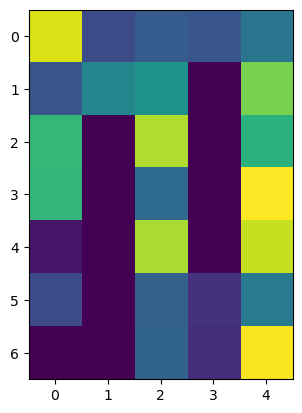

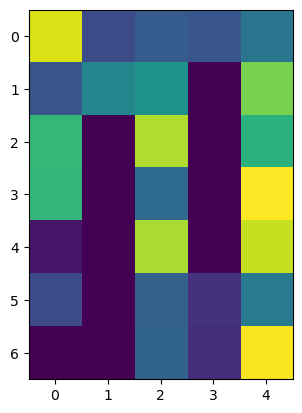

In [224]:
import matplotlib.pyplot as plt

channel_idx = 0
surf_idx = 2
energy_idx = 1
sample_idx = 4
plt.imshow(out[sample_idx, surf_idx, channel_idx, :, :, energy_idx].detach().numpy(), cmap='viridis')
plt.show()

plt.imshow(rotate_180_spatial(out_rotated)[sample_idx, surf_idx, channel_idx, :, :, energy_idx].detach().numpy())
plt.show()

In [225]:
mse = nn.MSELoss()

def compute_loss(pred, Y_flux, Y_pow, Y_keff, Y_wts):
    return (
        mse(pred['flux'], Y_flux) +
        mse(pred['pow'], Y_pow) +
        mse(pred['keff'], Y_keff) +
        mse(pred['wts'], Y_wts)
    )

In [226]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch

seed = 42
torch.manual_seed(seed)

# === Flatten tensors where necessary ===
X_flux_flat = X_flux.view(X_flux.size(0), -1).numpy()
X_wts_np    = X_wts.numpy()
Y_flux_flat = Y_flux.view(Y_flux.size(0), -1).numpy()
Y_pow_flat  = Y_pow.view(Y_pow.size(0), -1).numpy()  # <-- fix applied here
Y_keff_np   = Y_keff.view(-1, 1).numpy()
Y_wts_np    = Y_wts.numpy()

# === Create train/test splits in NumPy ===
(
    X_flux_train_np, X_flux_test_np,
    X_wts_train_np, X_wts_test_np,
    Y_flux_train_np, Y_flux_test_np,
    Y_pow_train_np, Y_pow_test_np,
    Y_keff_train_np, Y_keff_test_np,
    Y_wts_train_np, Y_wts_test_np
) = train_test_split(
    X_flux_flat, X_wts_np,
    Y_flux_flat, Y_pow_flat, Y_keff_np, Y_wts_np,
    test_size=0.2, random_state=42
)

# === Fit scalers only on training data ===
scalers = {
    'X_flux': StandardScaler().fit(X_flux_train_np),
    'X_wts': StandardScaler().fit(X_wts_train_np),
    'Y_flux': StandardScaler().fit(Y_flux_train_np),
    'Y_pow': StandardScaler().fit(Y_pow_train_np),
    'Y_keff': StandardScaler().fit(Y_keff_train_np),
    'Y_wts': StandardScaler().fit(Y_wts_train_np),
}

# === Transform both train and test sets ===
X_flux_train = torch.tensor(scalers['X_flux'].transform(X_flux_train_np), dtype=torch.float32).view(-1, *X_flux.shape[1:])
X_flux_test  = torch.tensor(scalers['X_flux'].transform(X_flux_test_np),  dtype=torch.float32).view(-1, *X_flux.shape[1:])

X_wts_train = torch.tensor(scalers['X_wts'].transform(X_wts_train_np), dtype=torch.float32)
X_wts_test  = torch.tensor(scalers['X_wts'].transform(X_wts_test_np),  dtype=torch.float32)

Y_flux_train = torch.tensor(scalers['Y_flux'].transform(Y_flux_train_np), dtype=torch.float32).view(-1, *Y_flux.shape[1:])
Y_flux_test  = torch.tensor(scalers['Y_flux'].transform(Y_flux_test_np),  dtype=torch.float32).view(-1, *Y_flux.shape[1:])

Y_pow_train = torch.tensor(scalers['Y_pow'].transform(Y_pow_train_np), dtype=torch.float32)
Y_pow_test  = torch.tensor(scalers['Y_pow'].transform(Y_pow_test_np),  dtype=torch.float32)

Y_keff_train = torch.tensor(scalers['Y_keff'].transform(Y_keff_train_np), dtype=torch.float32).squeeze(1)
Y_keff_test  = torch.tensor(scalers['Y_keff'].transform(Y_keff_test_np),  dtype=torch.float32).squeeze(1)

Y_wts_train = torch.tensor(scalers['Y_wts'].transform(Y_wts_train_np), dtype=torch.float32)
Y_wts_test  = torch.tensor(scalers['Y_wts'].transform(Y_wts_test_np),  dtype=torch.float32)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === 1. Wrap pre-normalized train and test tensors ===
train_set = TensorDataset(X_flux_train, X_wts_train, Y_flux_train, Y_pow_train, Y_keff_train, Y_wts_train)
test_set  = TensorDataset(X_flux_test,  X_wts_test,  Y_flux_test,  Y_pow_test,  Y_keff_test,  Y_wts_test)

# === 2. Create DataLoaders ===
batch_size = len(train_set)

train_loader = DataLoader(train_set, batch_size=batch_size)  # full-batch for now
test_loader = DataLoader(test_set, batch_size=len(test_set))

# === 3. Get one full batch from train set to define input_dim ===
X_flux_train, X_wts_train, Y_flux_train, Y_pow_train, Y_keff_train, Y_wts_train = next(iter(train_loader))

# === 4. Instantiate model with shape info ===
X_input_dim = X_flux_train.view(X_flux_train.size(0), -1).size(1) + X_wts_train.size(1)
model = EquivariantModel(
    hidden_encoder=12, 
    encoder_out=12, 
    upsample=True, 
    num_encoder_layers=3, 
    gnn_hidden=12, 
    gnn_out=12, 
    num_gnn_layers=3,
    hidden_decoder_channels=12, 
    hidden_decoder_coef=100, 
    hidden_decoder_keff=100, 
    hidden_decoder_pow=100, 
    num_decoder_layers=3
).to(device)

# Weight initialization
def init_weights(m):
    if isinstance(m, nn.Conv3d):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.ConvTranspose3d):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
            
model.apply(init_weights)

num_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {num_params}")

Total number of parameters: 21777066


In [242]:
from tqdm import tqdm
from torch.amp import autocast, GradScaler

scaler = GradScaler()

epochs = 1000
steps_per_epoch = len(train_loader)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# schedule = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer,
#     T_max=1000,
# )
# schedule = torch.optim.lr_scheduler.OneCycleLR(
#     optimizer,
#     max_lr=1e-2,
#     epochs=epochs,
#     steps_per_epoch=steps_per_epoch,
#     pct_start=0.1,           # 10% warm-up
#     anneal_strategy='cos',   # cosine decay
#     div_factor=25.0,         # initial LR = max_lr / div_factor
#     final_div_factor=1e4     # final LR = initial / final_div_factor
# )
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',              # or 'max'
    factor=0.5,              # new_lr = lr * factor
    patience=10,             # wait 10 epochs before reducing
    threshold=1e-4,          # minimum change to count as improvement
    min_lr=1e-6,             # don’t go lower than this
)
progress_bar = tqdm(range(epochs), desc="Training", position=0)

train_losses = []
test_losses = []
for epoch in progress_bar:
    model.train()

    for X_flux, X_wts, Y_flux, Y_pow, Y_keff, Y_wts in train_loader:
        optimizer.zero_grad()
        X_flux, X_wts = X_flux.to(device), X_wts.to(device)
        Y_flux, Y_pow, Y_keff, Y_wts = Y_flux.to(device), Y_pow.to(device), Y_keff.to(device), Y_wts.to(device)

        with autocast(str(device)):
            pred = model(X_flux, X_wts)
            loss = compute_loss(pred, Y_flux, Y_pow, Y_keff, Y_wts)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

    
    model.eval()
    with torch.no_grad():
        for X_flux_test, X_wts_test, Y_flux_test, Y_pow_test, Y_keff_test, Y_wts_test in test_loader:
            X_flux_test = X_flux_test.to(device)
            X_wts_test  = X_wts_test.to(device)
            Y_flux_test = Y_flux_test.to(device)
            Y_pow_test  = Y_pow_test.to(device)
            Y_keff_test = Y_keff_test.to(device)
            Y_wts_test  = Y_wts_test.to(device)

            pred_test = model(X_flux_test, X_wts_test)
            test_loss = compute_loss(pred_test, Y_flux_test, Y_pow_test, Y_keff_test, Y_wts_test)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    progress_bar.set_description(f"Epoch {epoch}/{epochs}: Train Loss = {loss.item():.4f} | Test Loss = {test_loss.item():.4f}")

# === 8. Evaluate on test set ===
model.eval()
with torch.no_grad():
    for X_flux_test, X_wts_test, Y_flux_test, Y_pow_test, Y_keff_test, Y_wts_test in test_loader:
        X_flux_test = X_flux_test.to(device)
        X_wts_test  = X_wts_test.to(device)
        Y_flux_test = Y_flux_test.to(device)
        Y_pow_test  = Y_pow_test.to(device)
        Y_keff_test = Y_keff_test.to(device)
        Y_wts_test  = Y_wts_test.to(device)

        pred_test = model(X_flux_test, X_wts_test)
        test_loss = compute_loss(pred_test, Y_flux_test, Y_pow_test, Y_keff_test, Y_wts_test)

print(f"Final Test Loss: {test_loss.item():.4f}")

Epoch 5/1000: Train Loss = 3.4168 | Test Loss = 10235401.0000:   1%|          | 6/1000 [01:07<3:04:59, 11.17s/it]          


KeyboardInterrupt: 

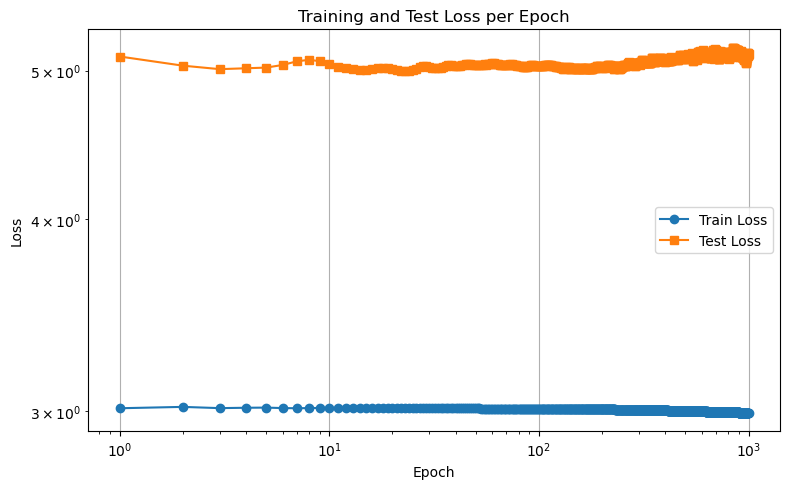

In [161]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, test_losses, label='Test Loss', marker='s')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss per Epoch')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=300)
plt.show()